# AI304 Unsupervised Learning Lab
## Notebook 3: Unsupervised Modelling & Clustering

In [4]:
# ─────────────────────────────────────────────
# Import libraries
# sklearn_extra provides KMedoids (not in standard sklearn)
# scipy provides linkage and dendrogram for hierarchical clustering
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("All libraries imported.")

All libraries imported.


In [5]:
# ─────────────────────────────────────────────
# Load feature-engineered data from Notebook 2
# daily_features → for labelling and plotting
# scaled_data    → the standardised matrix used for clustering
# ─────────────────────────────────────────────
daily_features = pd.read_csv("daily_features.csv", parse_dates=True, index_col='datetime')
scaled_data = np.load("scaled_data.npy")

print(f"daily_features shape: {daily_features.shape}")
print(f"scaled_data shape:    {scaled_data.shape}")

daily_features shape: (1433, 12)
scaled_data shape:    (1433, 10)


---
## Part A: Optimal K Selection (Elbow + Silhouette)

In [6]:
# ─────────────────────────────────────────────
# Elbow Method: plot inertia (sum of squared distances
# to nearest cluster centre) for k = 2 to 10.
# The 'elbow' point — where the rate of decrease flattens —
# indicates a good trade-off between compactness and complexity.
# ─────────────────────────────────────────────
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(scaled_data, labels))

print("Inertia and Silhouette computed for k = 2 to 10.")

Inertia and Silhouette computed for k = 2 to 10.


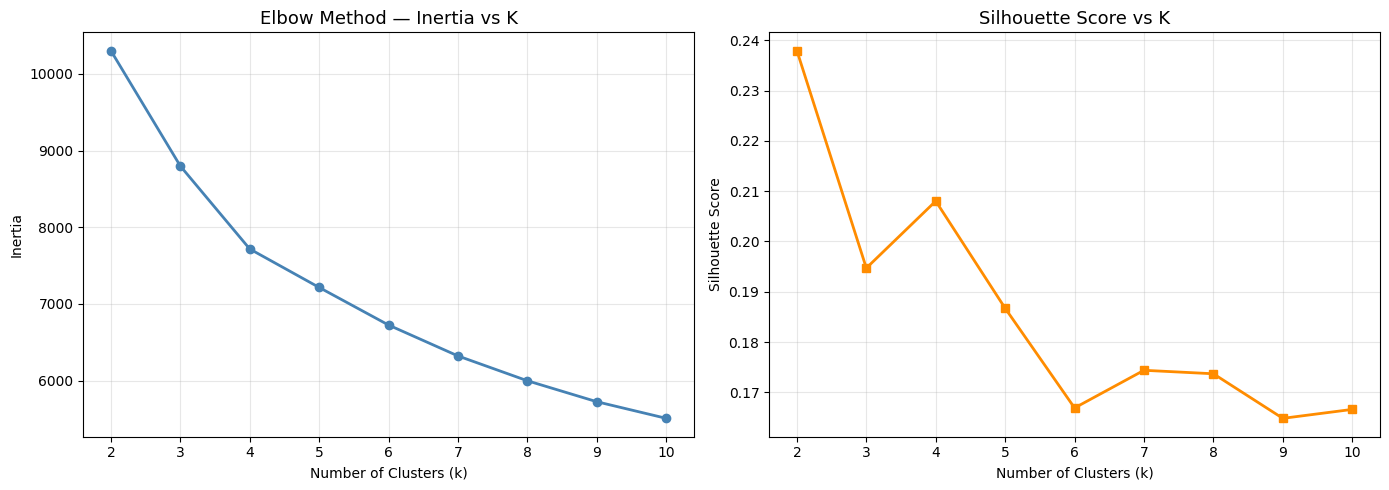

Best k by Silhouette Score: 2  (score = 0.2379)


In [7]:
# ─────────────────────────────────────────────
# Plot Elbow Curve and Silhouette Scores side by side
# Left  → Elbow: choose k at the 'kink'
# Right → Silhouette: higher is better (max = 1)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_range), inertia_values, 'o-', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Method — Inertia vs K", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

# Silhouette scores
axes[1].plot(list(k_range), silhouette_values, 's-', color='darkorange', linewidth=2)
axes[1].set_title("Silhouette Score vs K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouette_values.index(max(silhouette_values))]
print(f"Best k by Silhouette Score: {best_k}  (score = {max(silhouette_values):.4f})")

---
## Part B: K-Means Clustering

In [8]:
# ─────────────────────────────────────────────
# K-Means Clustering
# n_clusters=3  → chosen based on Elbow + Silhouette analysis
# random_state  → ensures reproducibility
# n_init=10     → runs 10 initialisations, picks best (default in sklearn ≥1.2)
# ─────────────────────────────────────────────
OPTIMAL_K = 3  # Update this if Elbow/Silhouette suggest differently

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

daily_features['kmeans_cluster'] = kmeans_labels

sil_km = silhouette_score(scaled_data, kmeans_labels)
print(f"K-Means Silhouette Score: {sil_km:.4f}")
print(f"Cluster counts:\n{pd.Series(kmeans_labels).value_counts().sort_index()}")

K-Means Silhouette Score: 0.1947
Cluster counts:
0    451
1    615
2    367
Name: count, dtype: int64


---
## Part C: K-Medoids Clustering

In [10]:
# ─────────────────────────────────────────────
# K-Medoids (using pyclustering - PAM algorithm)
# Since sklearn_extra is not available, we use pyclustering
# ─────────────────────────────────────────────

# Convert to numpy array (important for pyclustering)
data = np.array(scaled_data)

# Step 1: choose initial medoids (random indices)
np.random.seed(42)
initial_medoids = np.random.choice(len(data), OPTIMAL_K, replace=False).tolist()

# Step 2: apply K-Medoids
kmedoids_instance = kmedoids(data, initial_medoids)
kmedoids_instance.process()

# Step 3: get clusters (list of index lists)
clusters = kmedoids_instance.get_clusters()

# Step 4: convert clusters → labels (like sklearn output)
kmedoids_labels = np.zeros(len(data), dtype=int)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        kmedoids_labels[index] = cluster_id

# Step 5: store results
daily_features['kmedoids_cluster'] = kmedoids_labels

# Step 6: evaluation
sil_kmed = silhouette_score(data, kmedoids_labels)

print(f"K-Medoids Silhouette Score: {sil_kmed:.4f}")
print(f"Cluster counts:\n{pd.Series(kmedoids_labels).value_counts().sort_index()}")

K-Medoids Silhouette Score: 0.1899
Cluster counts:
0    373
1    426
2    634
Name: count, dtype: int64


---
## Part D: DBSCAN Clustering

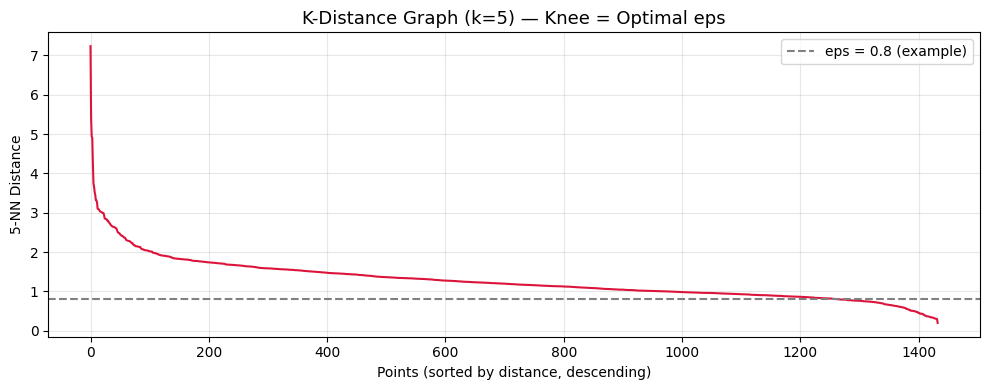

In [11]:
# ─────────────────────────────────────────────
# DBSCAN Hyperparameter Tuning — finding optimal eps
# We use the k-distance graph: for each point, compute the
# distance to its k-th nearest neighbour. The 'knee' in the
# sorted graph is a good candidate for eps.
# ─────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5  # Minimum points to form a dense region

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(scaled_data)
distances, _ = nbrs.kneighbors(scaled_data)

# Distance to the k-th nearest neighbour, sorted ascending
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='crimson', linewidth=1.5)
plt.title(f"K-Distance Graph (k={MIN_SAMPLES}) — Knee = Optimal eps", fontsize=13)
plt.xlabel("Points (sorted by distance, descending)")
plt.ylabel(f"{MIN_SAMPLES}-NN Distance")
plt.axhline(y=0.8, color='gray', linestyle='--', label='eps = 0.8 (example)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────
# DBSCAN Clustering
# eps         → neighbourhood radius (set from k-distance graph knee)
# min_samples → minimum points within eps to form a core point
# Label -1    → noise points (not assigned to any cluster)
# ─────────────────────────────────────────────
dbscan = DBSCAN(eps=0.8, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(scaled_data)

daily_features['dbscan_cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points.")
print(f"Cluster distribution:\n{pd.Series(dbscan_labels).value_counts().sort_index()}")

# Silhouette score only valid when there are ≥2 clusters and no only-noise
if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    sil_db = silhouette_score(scaled_data[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score (excl. noise): {sil_db:.4f}")

DBSCAN found 12 clusters and 1146 noise points.
Cluster distribution:
-1     1146
 0        5
 1       76
 2       19
 3        5
 4        5
 5       73
 6       25
 7       19
 8       44
 9        5
 10       6
 11       5
Name: count, dtype: int64
DBSCAN Silhouette Score (excl. noise): 0.1913


---
## Part E: Agglomerative (Hierarchical) Clustering

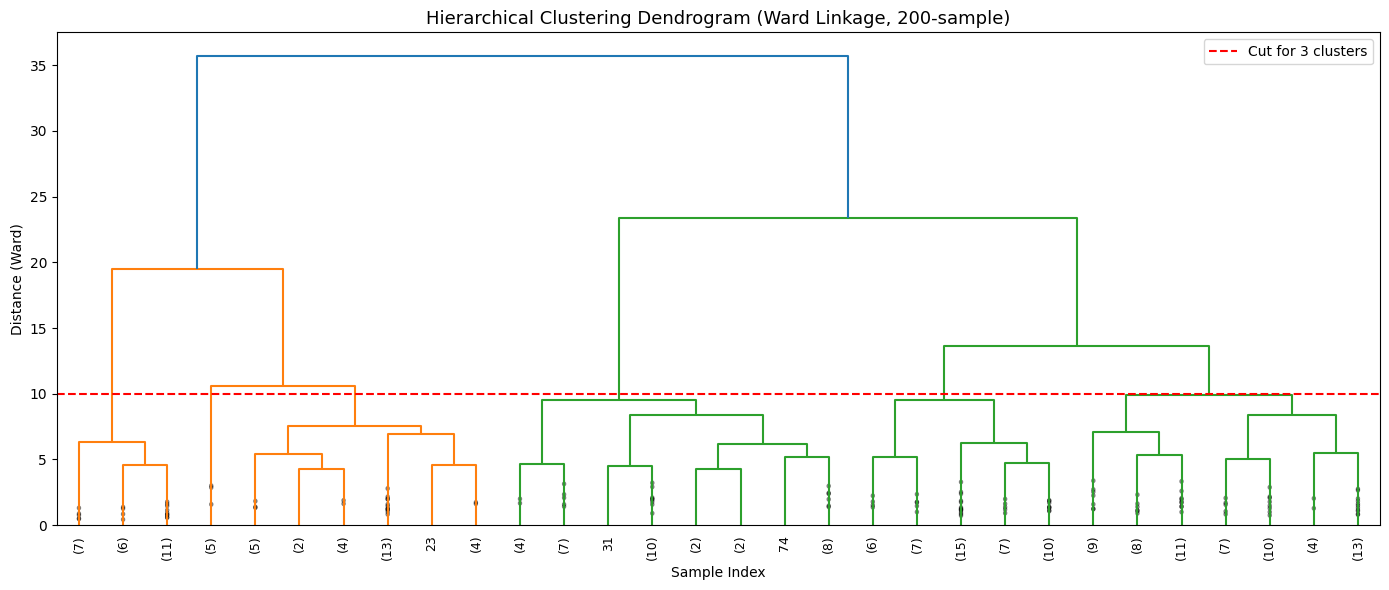

In [13]:
# ─────────────────────────────────────────────
# Dendrogram — visualises the hierarchical merge process.
# We use Ward linkage which minimises within-cluster variance.
# The number of horizontal cuts = number of clusters chosen.
# We use a sample of 200 days for readability.
# ─────────────────────────────────────────────
sample_size = min(200, len(scaled_data))
sample_idx = np.random.RandomState(42).choice(len(scaled_data), sample_size, replace=False)
sample_data = scaled_data[sample_idx]

# Compute linkage matrix using Ward method
Z = linkage(sample_data, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only last p merged clusters
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, 200-sample)", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Distance (Ward)")
plt.axhline(y=10, color='red', linestyle='--', label='Cut for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────
# Agglomerative Clustering on full dataset
# linkage='ward'  → minimises within-cluster variance at each merge
# n_clusters=3    → justified by dendrogram inspection
# ─────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(scaled_data)

daily_features['agg_cluster'] = agg_labels

sil_agg = silhouette_score(scaled_data, agg_labels)
print(f"Agglomerative Silhouette Score: {sil_agg:.4f}")
print(f"Cluster counts:\n{pd.Series(agg_labels).value_counts().sort_index()}")

Agglomerative Silhouette Score: 0.1635
Cluster counts:
0    670
1    563
2    200
Name: count, dtype: int64


---
## Part F: Model Comparison

    Algorithm  Silhouette Score  N Clusters
      K-Means          0.194711           3
    K-Medoids          0.189950           3
Agglomerative          0.163501           3


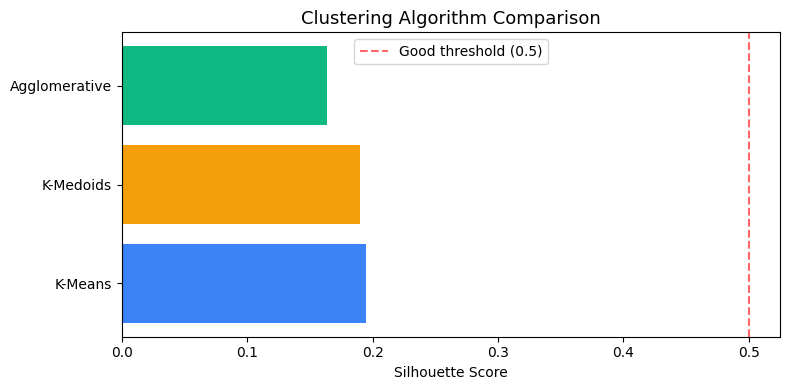

In [15]:
# ─────────────────────────────────────────────
# Compare all models by Silhouette Score
# Silhouette ranges from -1 (worst) to 1 (best).
# Scores above 0.5 indicate well-separated clusters.
# ─────────────────────────────────────────────
comparison = {
    'Algorithm': ['K-Means', 'K-Medoids', 'Agglomerative'],
    'Silhouette Score': [sil_km, sil_kmed, sil_agg],
    'N Clusters': [OPTIMAL_K, OPTIMAL_K, OPTIMAL_K]
}

comp_df = pd.DataFrame(comparison).sort_values('Silhouette Score', ascending=False)
print(comp_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3b82f6', '#f59e0b', '#10b981']
ax.barh(comp_df['Algorithm'], comp_df['Silhouette Score'], color=colors)
ax.set_xlabel("Silhouette Score")
ax.set_title("Clustering Algorithm Comparison", fontsize=13)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.6, label='Good threshold (0.5)')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────
# Save clustering results for Notebook 4 (Visualisation)
# ─────────────────────────────────────────────
daily_features.to_csv("clustered_features.csv")
print("Clustering results saved to 'clustered_features.csv'")
daily_features.head()

Clustering results saved to 'clustered_features.csv'


,mean_power,max_power,min_power,std_power,peak_to_avg_ratio,avg_kitchen,avg_laundry,avg_hvac,mean_voltage,std_voltage,day_of_week,is_weekend,kmeans_cluster,kmedoids_cluster,dbscan_cluster,agg_cluster
datetime,,,,,,,,,,,,,,,,
2006-12-16,3.053475,7.706,0.284,1.026338,2.523682,0.000000,1.378788,12.439394,236.243763,2.922896,5,1,2,0,-1,2
2006-12-17,2.354486,7.064,0.206,1.205795,3.000230,1.411806,2.907639,9.264583,240.087028,4.051467,6,1,2,0,-1,2
2006-12-18,1.530435,6.158,0.202,1.005074,4.023693,0.738194,1.820139,9.734722,241.231694,3.719576,0,0,2,0,-1,1
2006-12-19,1.157079,7.840,0.194,1.237602,6.775682,0.582639,5.279167,4.303472,241.999313,3.069492,1,0,2,0,-1,2
2006-12-20,1.545658,5.988,0.202,1.320968,3.874077,0.000000,1.838889,9.765972,242.308063,3.345704,2,0,2,0,-1,1


## Summary

| Algorithm | Strength | Weakness |
|-----------|----------|----------|
| **K-Means** | Fast, scalable | Assumes spherical clusters, sensitive to outliers |
| **K-Medoids** | Robust to outliers, interpretable centres | Slower (O(n²)) |
| **DBSCAN** | Finds arbitrary shapes, detects noise | Requires eps/min_samples tuning |
| **Agglomerative** | Hierarchical insight via dendrogram | Computationally expensive for large datasets |
